# Kinematic model and steering calibration

Step 5.5. Rolling radius of the slick tires, steering map, and the kinematic
bicycle model checked against low-slip data.

## Rolling radius, slick tires

The caliper gives 60 mm diameter, unloaded. Pushing the car by hand does not
work: disarmed, the drivers short the motors, the rear wheels brake and skid.
Three pushes over 3 m gave 30.4 / 30.5 / 31.3 mm. Skidding only loses wheel
angle, so those are upper bounds.

Driven runs instead: `drive_hold.py 0.2 0.0 14` (1 s ramps, ~2.6 m), distance
read on a tape, lateral drift added with Pythagoras.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bagtools as bt

dfs = bt.zero_time(bt.load('../data/rolling_radius_driven_parquet'))
js, drive = dfs['joint_states'], dfs['drive']

# tape distance and lateral drift per run [mm]
tape = [(2616, 30), (2610, 107), (2608, 100)]

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# each run is one burst of /drive messages
t = drive['t'].values
gaps = np.flatnonzero(np.diff(t) > 2.0)
starts = np.r_[t[0], t[gaps + 1]]
ends = np.r_[t[gaps], t[-1]]

rows = []
for t0, t1, (dx, dy) in zip(starts, ends, tape):
    before = bt.window(js, t0, t0 + 0.8)   # armed, speed 0
    after = bt.window(js, t1 - 0.8, t1)    # stopped, disarming
    dl = after['pl'].median() - before['pl'].median()
    dr = after['pr'].median() - before['pr'].median()
    dist = np.hypot(dx, dy) / 1000
    rows.append({'dist [m]': dist, 'left [rad]': dl, 'right [rad]': dr,
                 'r [mm]': 1000 * dist / ((dl + dr) / 2)})

runs = pd.DataFrame(rows).round(3)
runs

,dist [m],left [rad],right [rad],r [mm]
0,2.616,87.460,87.451,29.914
1,2.612,87.403,87.412,29.885
2,2.610,87.422,87.384,29.861


In [3]:
r = runs['r [mm]']
print(f"r = {r.mean():.2f} mm, sd {r.std():.3f} mm over {len(r)} runs")
print(f"vs caliper 30.0: {(r.mean() / 30.0 - 1) * 100:+.1f} %")
print(f"vs stock 34.15:  {(r.mean() / 34.15 - 1) * 100:+.1f} %")

r = 29.89 mm, sd 0.027 mm over 3 runs
vs caliper 30.0: -0.4 %
vs stock 34.15:  -12.5 %


**r = 29.9 mm**, runs within 0.2%. The 0.4% under the caliper is the tire
under load. A driven wheel slips slightly forward and reads a bit low; the
pushed runs bound it from above. The driven value is the one the firmware
needs: it is the radius the wheels have while the motors turn them.

With the stock value in the firmware, every m/s setpoint on slicks ran 12.5%
slow. Wheels still plateau at ~40 rad/s, so v_max on slicks is 1.20 m/s.

### Check after the firmware update

`WHEEL_RADIUS_M` set to 0.0299 and flashed. One more run, `drive_hold.py 0.2 0.0 12`,
IMU recorded too.

In [4]:
R_WHEEL = 0.0299

d = bt.zero_time(bt.load('../data/radius_check_parquet'))
js_c, drive_c = d['joint_states'], d['drive']
t0, t1 = drive_c['t'].iloc[0], drive_c['t'].iloc[-1]

plateau = bt.window(js_c, t0 + 4, t1 - 4)
print(f"wheel speed {plateau['wl'].mean():.3f} / {plateau['wr'].mean():.3f} rad/s, "
      f"setpoint {0.2 / R_WHEEL:.3f}")

before = bt.window(js_c, t0, t0 + 0.8)
after = bt.window(js_c, t1 - 0.8, t1)
angle = (after[['pl', 'pr']].median() - before[['pl', 'pr']].median()).mean()
dist = np.hypot(2568, 137) / 1000
print(f"r = {1000 * dist / angle:.2f} mm")

wheel speed 6.697 / 6.688 rad/s, setpoint 6.689
r = 29.75 mm


Setpoints now come out right on slicks. This run gives 0.5% under the three
above, within what the tape and the lateral correction allow. 0.0299 stays.

## Steering map

`SERVO_ANGLE_MAX_DEG = 30` was never measured. Static measurement, car on the
floor, disarmed, steering set through `/drive` with speed 0. A ruler held on edge
against the outer sidewall of each tire; distance from the nearest tile joint at
both ends of the ruler, 200 mm apart (shorter where the chassis was in the way).
Joints on the two sides are parallel, and the rear wheels give the vehicle axis,
so the car does not need to be aligned to the tiles.

Readings in mm: front and back end of the ruler, and their spacing.

In [5]:
L = 0.173
T = 0.1745

rear = {'left': (92, 88.5, 200), 'right': (98, 96, 200)}

# cmd [rad]: (left front, left back, left base, right front, right back, right base)
front = {
    0.00: (85, 94, 200, 97.5, 97, 200),
    0.15: (71.5, 109, 200, 112, 84, 200),
    0.30: (71.5, 115, 120, 127.5, 71, 200),
    0.52: (15, 123, 180, 148, 58, 200),
    -0.15: (100.5, 78.5, 200, 83, 113.5, 200),
    -0.30: (114, 67, 200, 72.5, 127, 200),
    -0.52: (129, 56, 200, 76, 130.5, 120),
}


def wheel_angle(side, d_front, d_back, base):
    # positive = pointing left; the left joint is on the left, the right one on the right
    d = d_back - d_front if side == 'left' else d_front - d_back
    return np.degrees(np.arctan(d / base))


axis = (wheel_angle('left', *rear['left']) + wheel_angle('right', *rear['right'])) / 2
print(f"rear wheels: {wheel_angle('left', *rear['left']):+.2f} / "
      f"{wheel_angle('right', *rear['right']):+.2f} deg, axis {axis:+.2f}")

rear wheels: -1.00 / +0.57 deg, axis -0.21


Each front wheel alone would turn the car about its own center. For a left turn
with the center at distance $R$ from the rear axle midpoint:

$$\cot\delta_L = \frac{R - T/2}{L}, \qquad \cot\delta_R = \frac{R + T/2}{L}
\quad\Rightarrow\quad \cot\delta = \frac{R}{L} = \frac{\cot\delta_L + \cot\delta_R}{2}$$

so the bicycle angle comes from the mean of the cotangents, not of the angles.

In [6]:
rows = []
for cmd, (lf, lb, lB, rf, rb, rB) in sorted(front.items()):
    dl = wheel_angle('left', lf, lb, lB) - axis
    dr = wheel_angle('right', rf, rb, rB) - axis
    cot = (1 / np.tan(np.radians(dl)) + 1 / np.tan(np.radians(dr))) / 2
    rows.append({'cmd [deg]': np.degrees(cmd), 'left [deg]': dl, 'right [deg]': dr,
                 'delta [deg]': np.degrees(np.arctan(1 / cot))})

steer = pd.DataFrame(rows).round(2)
steer

,cmd [deg],left [deg],right [deg],delta [deg]
0,-29.79,-19.84,-24.21,-21.82
1,-17.19,-13.01,-15.03,-13.95
2,-8.59,-6.06,-8.46,-7.06
3,0.00,2.79,0.36,0.63
4,8.59,10.83,8.18,9.33
5,17.19,20.14,15.99,17.83
6,29.79,31.18,24.44,27.43


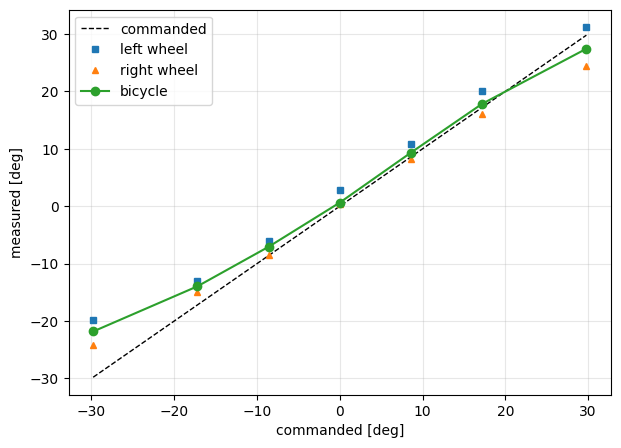

In [7]:
c = steer['cmd [deg]']
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(c, c, 'k--', lw=1, label='commanded')
ax.plot(c, steer['left [deg]'], 's', ms=4, label='left wheel')
ax.plot(c, steer['right [deg]'], '^', ms=4, label='right wheel')
ax.plot(c, steer['delta [deg]'], 'o-', label='bicycle')
ax.set_xlabel('commanded [deg]')
ax.set_ylabel('measured [deg]')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

At zero command the wheels sit at +2.8 / +0.4 deg: 2.4 deg of toe-out, and a
bicycle angle of **+0.6 deg**, the same as the gyro gave on the straight run
(+0.59 deg). A repeat at zero after the sweep landed within 0.3 deg.

Turning left the gain is 1.0 up to 17 deg and drops to 0.9 at full lock. Turning
right it falls from 0.9 to 0.75. Full lock is **+27.4 / -21.8 deg**, not +-30.
The inner wheel always steers more than the outer one, as Ackermann wants.

A line per side leaves residuals up to 1.2 deg, four times the measurement
error, so the map is kept as the measured table with linear interpolation, in
both directions.

In [8]:
def cmd_to_delta(cmd_deg):
    return np.interp(cmd_deg, steer['cmd [deg]'], steer['delta [deg]'])


def delta_to_cmd(delta_deg):
    return np.interp(delta_deg, steer['delta [deg]'], steer['cmd [deg]'])


print(f"cmd for a straight line: {delta_to_cmd(0.0):+.2f} deg")
print(f"reachable delta: {steer['delta [deg]'].min():+.1f} to {steer['delta [deg]'].max():+.1f} deg")

cmd for a straight line: -0.70 deg
reachable delta: -21.8 to +27.4 deg


## Kinematic model against the gyro

Bicycle model about the rear axle midpoint, no slip:

$$\dot x = v\cos\psi, \qquad \dot y = v\sin\psi, \qquad \dot\psi = \frac{v\tan\delta}{L}$$

with $v$ from the wheels and $\delta$ from the map above. Checked on slow circles
(0.2 m/s, a_y under 0.1 m/s^2) in both directions. On most of them the circle
was marked with tape at the outer edge of the outer rear tire, half a lap
apart, which gives the real radius independently of the wheels.

In [9]:
TIRE_W = 0.026


def split_runs(drive):
    t = drive['t'].values
    gaps = np.flatnonzero(np.diff(t) > 2.0)
    return np.r_[t[0], t[gaps + 1]], np.r_[t[gaps], t[-1]]


# (bag, run, tape diameter [mm]); kin_circles run 0 was disturbed, run 5 lifted
circles = [('steering_circles', 0, 850), ('steering_circles', 2, 995),
           ('kin_circles', 1, 1280), ('kin_circles', 2, 1650),
           ('kin_circles', 3, None), ('kin_circles', 4, 2580),
           ('kin_circles', 6, None), ('kin_circles', 7, None), ('kin_circles', 8, 2310)]

rows, series = [], []
for bag in ['steering_circles', 'kin_circles']:
    d = bt.zero_time(bt.load(f'../data/{bag}_parquet'))
    starts, ends = split_runs(d['drive'])
    bias = bt.window(d['imu_data_raw'], 0, starts[0] - 0.5)['gz'].mean()
    df = bt.merge_asof({k: d[k] for k in ['imu_data_raw', 'joint_states', 'steering_angle']})
    df['r'] = (df['gz'] - bias).rolling(25, center=True).mean()    # 0.5 s
    df['v'] = R_WHEEL * (df['wl'] + df['wr']) / 2
    df['r_kin'] = df['v'] * np.tan(np.radians(cmd_to_delta(np.degrees(df['steer'])))) / L

    for b, i, D in circles:
        if b != bag:
            continue
        series.append(bt.window(df, starts[i] + 1, ends[i]).dropna(subset=['r', 'r_kin']))
        steady = bt.window(df, starts[i] + 3, ends[i] - 2)
        cmd = np.degrees(steady['steer'].median())
        delta = cmd_to_delta(cmd)
        row = {'cmd [deg]': cmd, 'delta [deg]': delta,
               'r [rad/s]': steady['r'].mean(), 'r_kin [rad/s]': steady['r_kin'].mean(),
               'R_geom [m]': L / np.tan(np.radians(abs(delta)))}
        if D is not None:
            R_tape = D / 2000 - T / 2 - TIRE_W / 2
            row['R_tape [m]'] = R_tape
            row['v_true / v_wheels'] = abs(row['r [rad/s]']) * R_tape / steady['v'].mean()
            row['scrub'] = (R_tape + T / 2) / (R_tape - T / 2) - 1
        rows.append(row)

circ = pd.DataFrame(rows).round(3)
circ

,cmd [deg],delta [deg],r [rad/s],r_kin [rad/s],R_geom [m],R_tape [m],v_true / v_wheels,scrub
0,29.794,27.430,0.524,0.600,0.333,0.325,0.851,0.735
1,-29.794,-21.820,-0.409,-0.463,0.432,0.397,0.812,0.563
2,17.189,17.829,0.318,0.372,0.538,0.540,0.857,0.386
3,-17.189,-13.949,-0.255,-0.287,0.697,0.725,0.925,0.274
4,8.594,9.334,0.159,0.190,1.052,NaN,NaN,NaN
5,8.594,9.334,0.158,0.190,1.052,1.190,0.940,0.158
6,-14.324,-11.654,-0.195,-0.238,0.839,NaN,NaN,NaN
7,-11.459,-9.359,-0.180,-0.191,1.050,NaN,NaN,NaN
8,-11.459,-9.359,-0.179,-0.191,1.050,1.055,0.946,0.180


yaw rate RMSE 0.040 rad/s over 12551 samples, NRMSE 4.1 % of range


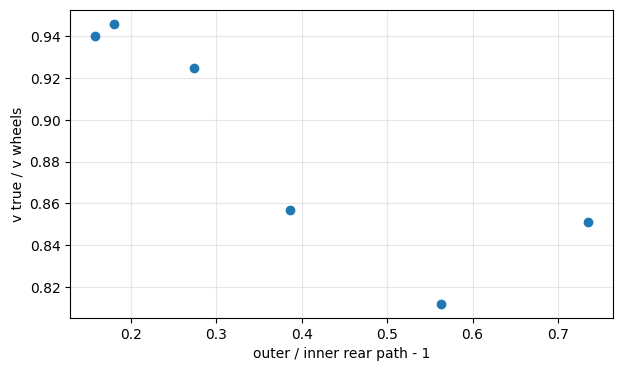

In [10]:
a = pd.concat(series)
err = a['r'] - a['r_kin']
rmse = np.sqrt((err**2).mean())
print(f"yaw rate RMSE {rmse:.3f} rad/s over {len(a)} samples, "
      f"NRMSE {100 * rmse / (a['r'].max() - a['r'].min()):.1f} % of range")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(circ['scrub'], circ['v_true / v_wheels'], 'o')
ax.set_xlabel('outer / inner rear path - 1')
ax.set_ylabel('v true / v wheels')
ax.grid(alpha=0.3)
plt.show()

The radius follows the steering map within 5% on four circles out of six
(+13% at +0.15, -8% at -0.52). The speed does not: the car covers 81-95% of what
the wheels turn, in general less the tighter the circle. That is the spool. Both wheels
turn at the same speed while the outer one needs up to 74% more path, and the
axle ends up pushing with both wheels slipping forward.

So the measured yaw rate is 82-94% of the kinematic prediction at 0.2 m/s, NRMSE
4.1% of range over all runs with ramps. The error is systematic, not noise: taking wheel
speed as vehicle speed is wrong in every tight turn, whatever the friction. It
goes into 5.9 as speed loss against curvature, and into 5.7: a_y from wheel
speed times r comes out high.